# Preconditioning experiment for operator GD on $S^1$

## Goal of the experiment

This experiment is designed to test whether low-frequency residual components can be made to converge at roughly the same rate by preconditioning the empirical operator gradient descent dynamics on $S^1$.

The main object of interest is not just whether preconditioning helps overall convergence, but whether it specifically reduces the mode-dependent rate differences that appear in the baseline spectral-bias dynamics.

We compare three flows:

1. **baseline** operator gradient descent using the empirical operator $A$,
2. **theory-preconditioned** gradient descent using a preconditioner built from the finite-$n$ diagonal benchmark $\Lambda^{(n)}$,
3. **empirical-preconditioned** gradient descent using the actual compressed low-frequency block $C$.

The empirical-preconditioned flow acts as a block-oracle reference. This lets us test whether the theory-driven construction is close to the best low-block correction available from the sampled operator itself.

---

## Mathematical setup

We parameterize the circle by an angle $\gamma \in [0,2\pi)$ and embed it as
$$
x(\gamma) = (\cos\gamma,\sin\gamma).
$$

For each run, we sample training angles
$$
\gamma_1,\dots,\gamma_n \overset{iid}{\sim} \mathrm{Unif}[0,2\pi).
$$

We evaluate the target function on these sampled points. In the first clean experiment, the target is the low-frequency Fourier mixture
$$
f^*(\gamma)
=
1 + 0.9\cos(\gamma) + 0.5\cos(2\gamma) + 0.35\cos(3\gamma).
$$

The kernel matrix is built from the analytic infinite-width bias NTK on the circle:
$$
K_{ij} = \Theta(\gamma_i,\gamma_j),
$$
and the empirical operator is the normalized matrix
$$
A = \frac{1}{n}K.
$$

This normalization is important because $A$ is the discrete analogue of the continuum integral operator.

---

## Sampled Fourier block

To probe and correct the low-frequency structure, we build the real Fourier basis up to frequency $K_{\max}$:
$$
\phi_0(\gamma)=1,
$$
$$
\phi_{k,c}(\gamma)=\sqrt{2}\cos(k\gamma), \qquad
\phi_{k,s}(\gamma)=\sqrt{2}\sin(k\gamma),
\qquad k=1,\dots,K_{\max}.
$$

Evaluating these basis functions on the sampled training angles gives the matrix
$$
\Phi \in \mathbb{R}^{n\times d},
\qquad d=2K_{\max}+1.
$$

We then form the sampled Gram matrix
$$
G=\frac{1}{n}\Phi^\top \Phi,
$$
the compressed bilinear form
$$
H=\frac{1}{n}\Phi^\top A\Phi,
$$
and the effective sampled low-block operator
$$
C = G^{-1}H.
$$

The matrix $C$ is the key empirical object: it describes how the empirical operator acts on the sampled Fourier block in coefficient coordinates.

---

## Finite-$n$ theory benchmark

From the continuum eigenvalues $\lambda_k$, we build the finite-$n$ diagonal benchmark
$$
\lambda_p^{(n)}
=
\left(1-\frac{1}{n}\right)\lambda_{k_p}
+
\frac{1}{n}g(0),
$$
where $k_p$ is the frequency associated with basis column $p$, and
$$
g(0)=\Theta(x,x)
$$
is the kernel diagonal value.

This defines the diagonal matrix
$$
\Lambda^{(n)}=\mathrm{diag}(\lambda_p^{(n)}).
$$

The theory question is whether $C$ is close enough to $\Lambda^{(n)}$ that a preconditioner built only from $\Lambda^{(n)}$ already captures the essential low-block correction.

---

## Flows compared in this notebook

### 1. Baseline flow

The unpreconditioned dynamics use the empirical operator directly:
$$
y_{t+1} = y_t - \eta A r_t,
\qquad
r_t = y_t - y^*.
$$

This is the reference spectral-bias dynamics.

### 2. Theory-preconditioned flow

We define the theory inverse scaling matrix
$$
M_{\mathrm{th}} = (\Lambda^{(n)} + \tau I)^{-1},
$$
and the sample-space preconditioner
$$
P_{\mathrm{th}} = \frac{1}{n}\Phi M_{\mathrm{th}} G^{-1}\Phi^\top.
$$

The resulting operator used in gradient descent is
$$
B_{\mathrm{th}} = P_{\mathrm{th}}A.
$$

This is the main object of interest, because it is built from the lemma-driven diagonal theory.

### 3. Empirical-preconditioned flow

We also define the block-oracle inverse scaling
$$
M_{\mathrm{emp}} = (C + (\tau+\mathrm{reg})I)^{-1},
$$
and the associated preconditioner
$$
P_{\mathrm{emp}} = \frac{1}{n}\Phi M_{\mathrm{emp}} G^{-1}\Phi^\top.
$$

This gives the operator
$$
B_{\mathrm{emp}} = P_{\mathrm{emp}}A.
$$

This serves as an empirical low-block reference: if this works much better than the theory version, then the issue is likely the approximation $C \approx \Lambda^{(n)}$, not the general preconditioning idea.

---

## Main scientific questions

This notebook is built to answer two main questions.

### 1. Does preconditioning flatten the low-mode convergence rates?

In the baseline flow, low modes decay at different rates because the operator spectrum is non-uniform.

The main question is whether, after preconditioning, the active low-frequency residual components decay much more uniformly.

### 2. How close is the theory preconditioner to the empirical block-oracle?

We compare the theory-driven construction against the empirical low-block correction to see whether the theoretical diagonal approximation is already accurate enough for practical preconditioning.

---

## Residual mode curves

For each flow, we record the train residual trajectory
$$
r_t = y_t - y^*,
$$
and project it onto sampled low-frequency Fourier directions.

If $\Phi_{\mathrm{unit}}$ denotes the columnwise sample-$\ell_2$ normalized basis matrix, then the raw mode projections are
$$
\alpha_p(t) = \langle r_t, \phi^{\mathrm{unit}}_p \rangle.
$$

To compare rates cleanly, we normalize by the initial magnitude:
$$
\mathrm{mode\_curve}_p(t)
=
\frac{|\alpha_p(t)|}{|\alpha_p(0)|}.
$$

These normalized residual mode curves are the primary dynamical observable in the notebook.

---

## Static diagnostics recorded

To understand why the flows behave as they do, we also compare the key low-block objects:

- how close $C$ is to $\Lambda^{(n)}$,
- how close $M_{\mathrm{th}}$ is to $M_{\mathrm{emp}}$,
- how close $P_{\mathrm{th}}$ is to $P_{\mathrm{emp}}$,
- how close $B_{\mathrm{th}}$ is to $B_{\mathrm{emp}}$,
- and how close the post-preconditioning compressed operators $C_{\mathrm{th}}$ and $C_{\mathrm{emp}}$ are.

These diagnostics help separate two issues:

- whether preconditioning works in principle,
- and whether the theory-based approximation is accurate enough to realize that improvement.

---

## What success looks like

The expected picture is:

- **baseline:** active modes $k=0,1,2,3$ decay at visibly different rates,
- **theory-preconditioned:** those active modes align substantially better,
- **empirical-preconditioned:** gives the strongest low-block alignment and acts as a reference.

If the theory-preconditioned curves are already close to the empirical-preconditioned ones, then the finite-$n$ diagonal benchmark is doing a good job.

---

## What we will analyze in this notebook

In this notebook, we will study:

1. how the baseline, theory-preconditioned, and empirical-preconditioned mode curves compare,
2. whether the active low-frequency residual modes collapse more tightly under preconditioning,
3. how the object-level diagnostics vary with $n$,
4. how close the theoretical and empirical preconditioners are,
5. and whether the empirical block-oracle provides only a small correction beyond the theoretical construction.

The central empirical story is therefore:

- baseline operator GD exhibits spectral-bias mode separation,
- low-block preconditioning should flatten those rates,
- and the key test is whether the theory-driven preconditioner is already close to the empirical low-block oracle.

In [3]:
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print("Project root added to sys.path:", ROOT)

from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
import jax.numpy as jnp
from utils.artifacts_io import latest_run_dir, load_manifest, npz
from collections import defaultdict

Project root added to sys.path: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments


In [4]:
results_dir = Path("../results/")
experiments = results_dir.glob("kernel_circle_preconditioning*")
for exp in experiments:
    print(exp)

../results/kernel_circle_preconditioning_kmax4
../results/kernel_circle_preconditioning_high_frequency_target
../results/kernel_circle_preconditioning_high_frequency_target_all_preconditioned
../results/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies


In [5]:
BASE = "../results"
EXP_NAME = "kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies"

plot_path = Path("plots") / EXP_NAME
plot_path.mkdir(parents=True, exist_ok=True)
print("Plots will be saved to:", plot_path)

Plots will be saved to: plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies


In [6]:
run_dir = latest_run_dir(BASE, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE}")

manifest = load_manifest(run_dir)
probe = npz(run_dir, manifest["probe_geometry"])

print("Loaded run dir:", run_dir)
print("Available run count:", len(manifest["runs"]))
print("n_trains:", manifest["meta"]["n_trains"])
print("seeds:", manifest["meta"]["seeds"])
print("K_max:", manifest["meta"]["K_max"])
print("kernel:", manifest["meta"]["kernel"])
print("steps:", manifest["meta"]["steps"])
print("eta:", manifest["meta"]["eta"])
print("tau:", manifest["meta"]["tau"])
print("reg:", manifest["meta"]["reg"])
print("n_probe:", manifest["meta"]["n_probe"])
print("mode_compare:", manifest["meta"]["mode_compare"])

gamma_probe = probe["gamma_probe"]
X_probe = probe["X_probe"]
y_target_probe = probe["y_target_probe"]

print("Probe grid shape:", gamma_probe.shape)
print("Probe target shape:", y_target_probe.shape)

Loaded run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/20260408-135208-41f97490
Available run count: 60
n_trains: [1024, 2048, 4096, 8192, 16384, 32768]
seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
K_max: 8
kernel: bias
steps: 2000
eta: 0.08
tau: 0.0
reg: 1e-08
n_probe: 2048
mode_compare: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Probe grid shape: (2048,)
Probe target shape: (2048,)


In [7]:
runs = {}
for run_key, rel_path in manifest["runs"].items():
    runs[run_key] = npz(run_dir, rel_path)

print("Loaded per-run files:", len(runs))
list(runs.keys())[:5]


Loaded per-run files: 60


['size_1024_seed_0',
 'size_1024_seed_1',
 'size_1024_seed_2',
 'size_1024_seed_3',
 'size_1024_seed_4']

In [8]:
def parse_run_key(run_key: str):
    # expected format: size_<n>_seed_<s>
    parts = run_key.split("_")
    n = int(parts[1])
    seed = int(parts[3])
    return n, seed


def _maybe(arrs, key, default=None):
    return arrs[key] if key in arrs else default


def _scalar(arrs, key, default=np.nan):
    if key not in arrs:
        return default
    return float(np.ravel(arrs[key])[0])


def unpack_run(run_key: str, arrs) -> dict:
    n, seed = parse_run_key(run_key)
    out = {
        "run_key": run_key,
        "n": n,
        "seed": seed,
        # Required for current notebook plots
        "mode_names": arrs["mode_names"],
        "mode_curves_base": arrs["mode_curves_base"],
        "mode_curves_th": arrs["mode_curves_th"],
        "mode_curves_emp": arrs["mode_curves_emp"],
        "y_pred_probe_base_final": arrs["y_pred_probe_base_final"],
        "y_pred_probe_th_final": arrs["y_pred_probe_th_final"],
        "y_pred_probe_emp_final": arrs["y_pred_probe_emp_final"],
        # Diagnostics used in METRICS plots
        "C_vs_Lambda_max": _scalar(arrs, "C_vs_Lambda_max"),
        "M_th_vs_emp_max": _scalar(arrs, "M_th_vs_emp_max"),
        "P_th_vs_emp_max": _scalar(arrs, "P_th_vs_emp_max"),
        "B_th_vs_emp_max": _scalar(arrs, "B_th_vs_emp_max"),
        "C_th_vs_emp_max": _scalar(arrs, "C_th_vs_emp_max"),
        # Optional (available in full runs or legacy runs)
        "C_vs_Lambda_fro": _scalar(arrs, "C_vs_Lambda_fro"),
        "M_th_vs_emp_fro": _scalar(arrs, "M_th_vs_emp_fro"),
        "P_th_vs_emp_fro": _scalar(arrs, "P_th_vs_emp_fro"),
        "B_th_vs_emp_fro": _scalar(arrs, "B_th_vs_emp_fro"),
        "C_th_vs_emp_fro": _scalar(arrs, "C_th_vs_emp_fro"),
        "loss_base": _maybe(arrs, "loss_base"),
        "loss_th": _maybe(arrs, "loss_th"),
        "loss_emp": _maybe(arrs, "loss_emp"),
        "eta": _scalar(arrs, "eta"),

        "C": _maybe(arrs, "C"),
        "C_th": _maybe(arrs, "C_th"),
        "C_emp": _maybe(arrs, "C_emp"),
        "lambda_n_diag": _maybe(arrs, "lambda_n_diag"),
        # heavy/full-only
        "A": _maybe(arrs, "A"),
        "P_th": _maybe(arrs, "P_th"),
        "P_emp": _maybe(arrs, "P_emp"),
        "B_th": _maybe(arrs, "B_th"),
        "B_emp": _maybe(arrs, "B_emp"),
        "r_train_base": _maybe(arrs, "r_train_base"),
        "r_train_th": _maybe(arrs, "r_train_th"),
        "r_train_emp": _maybe(arrs, "r_train_emp"),
        "mode_proj_base": _maybe(arrs, "mode_proj_base"),
        "mode_proj_th": _maybe(arrs, "mode_proj_th"),
        "mode_proj_emp": _maybe(arrs, "mode_proj_emp"),
    }
    return out


A = {run_key: unpack_run(run_key, arrs) for run_key, arrs in runs.items()}
print("Unpacked runs:", len(A))

by_n = defaultdict(list)
for run_key, a in A.items():
    by_n[a["n"]].append(a)

for n in sorted(by_n):
    seeds = sorted(x["seed"] for x in by_n[n])
    print(f"n={n:4d}  runs={len(by_n[n])}  seeds={seeds}")

Unpacked runs: 60
n=1024  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=2048  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=4096  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=8192  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=16384  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=32768  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/precond_diagnostic_C_vs_Lambda_max.png


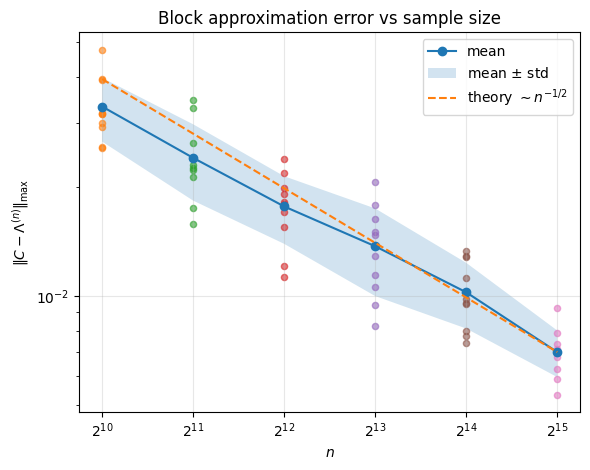

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/precond_diagnostic_P_th_vs_emp_max.png


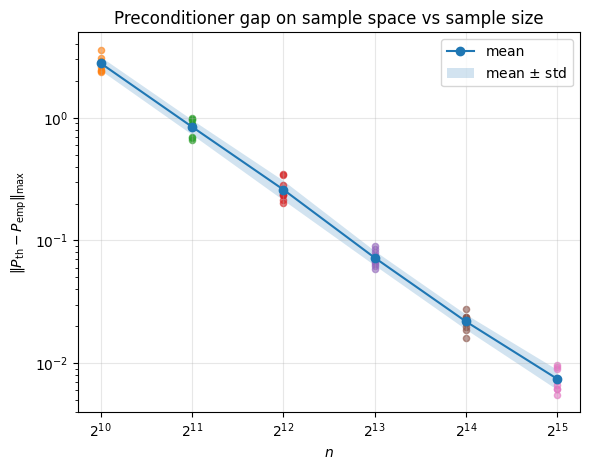

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/precond_diagnostic_B_th_vs_emp_max.png


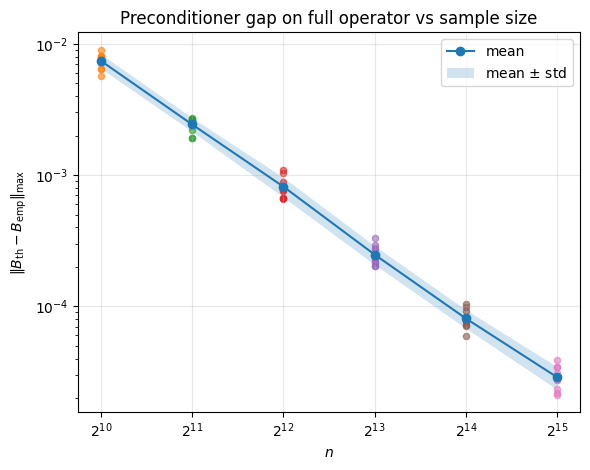

In [55]:
delta = 0.05
d = len(by_n[sorted(by_n.keys())[0]][0]["mode_names"])
kappa = 1.5

def theory_gram(ns, d=d, delta=delta):
    return np.sqrt(8.0 * np.log(2.0 * d**2 / delta) / ns)

def theory_comp(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(32.0 * kappa**2 * np.log(2.0 * d**2 / delta) / ns)

# use sup norm bound |lambda_k^(n)| <= kappa + g0/n, or just a fixed bound
Lambda_bound = kappa



METRICS = [
    ("C_vs_Lambda_max", r"$\|C-\Lambda^{(n)}\|_{\max}$", "Block approximation error"),
    ("P_th_vs_emp_max", r"$\|P_{\mathrm{th}}-P_{\mathrm{emp}}\|_{\max}$", "Preconditioner gap on sample space"),
    ("B_th_vs_emp_max", r"$\|B_{\mathrm{th}}-B_{\mathrm{emp}}\|_{\max}$", "Preconditioner gap on full operator"),
]


def aggregate_metric_by_n(by_n, metric_name: str):
    ns = sorted(by_n.keys())
    means, stds, mins, maxs, all_vals = [], [], [], [], []

    for n in ns:
        vals = np.array([run[metric_name] for run in by_n[n]], dtype=float)
        vals = vals[np.isfinite(vals)]

        means.append(vals.mean() if len(vals) else np.nan)
        stds.append(vals.std() if len(vals) else np.nan)
        mins.append(vals.min() if len(vals) else np.nan)
        maxs.append(vals.max() if len(vals) else np.nan)
        all_vals.append(vals)

    return {
        "ns": np.array(ns, dtype=int),
        "mean": np.array(means, dtype=float),
        "std": np.array(stds, dtype=float),
        "min": np.array(mins, dtype=float),
        "max": np.array(maxs, dtype=float),
        "all": all_vals,
    }


agg = {name: aggregate_metric_by_n(by_n, name) for name, _, _ in METRICS}

for metric_name, label, title in METRICS:
    plt.figure(figsize=(6, 4.8))

    d = agg[metric_name]
    ns = d["ns"]
    mean = d["mean"]
    std = d["std"]

    plt.plot(ns, mean, marker="o", label="mean")
    plt.fill_between(ns, mean - std, mean + std, alpha=0.2, label=r"mean $\pm$ std")

    for i, n in enumerate(ns):
        vals = d["all"][i]
        if len(vals):
            plt.scatter(np.full_like(vals, n, dtype=float), vals, s=20, alpha=0.6)

    if metric_name == "C_vs_Lambda_max":
        proxy_C = theory_comp(ns) + Lambda_bound * theory_gram(ns)
        scale = mean[-1] / proxy_C[-1]
        plt.plot(ns, scale * proxy_C, linestyle="--", label=r"theory $\sim n^{-1/2}$")

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel(r"$n$")
    plt.ylabel(label)
    plt.title(f"{title} vs sample size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = plot_path / f"precond_diagnostic_{metric_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()

In [40]:
A.keys()

dict_keys(['size_1024_seed_0', 'size_1024_seed_1', 'size_1024_seed_2', 'size_1024_seed_3', 'size_1024_seed_4', 'size_1024_seed_5', 'size_1024_seed_6', 'size_1024_seed_7', 'size_1024_seed_8', 'size_1024_seed_9', 'size_2048_seed_0', 'size_2048_seed_1', 'size_2048_seed_2', 'size_2048_seed_3', 'size_2048_seed_4', 'size_2048_seed_5', 'size_2048_seed_6', 'size_2048_seed_7', 'size_2048_seed_8', 'size_2048_seed_9', 'size_4096_seed_0', 'size_4096_seed_1', 'size_4096_seed_2', 'size_4096_seed_3', 'size_4096_seed_4', 'size_4096_seed_5', 'size_4096_seed_6', 'size_4096_seed_7', 'size_4096_seed_8', 'size_4096_seed_9', 'size_8192_seed_0', 'size_8192_seed_1', 'size_8192_seed_2', 'size_8192_seed_3', 'size_8192_seed_4', 'size_8192_seed_5', 'size_8192_seed_6', 'size_8192_seed_7', 'size_8192_seed_8', 'size_8192_seed_9', 'size_16384_seed_0', 'size_16384_seed_1', 'size_16384_seed_2', 'size_16384_seed_3', 'size_16384_seed_4', 'size_16384_seed_5', 'size_16384_seed_6', 'size_16384_seed_7', 'size_16384_seed_8', 

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/full_residual_decay_from_loss.png


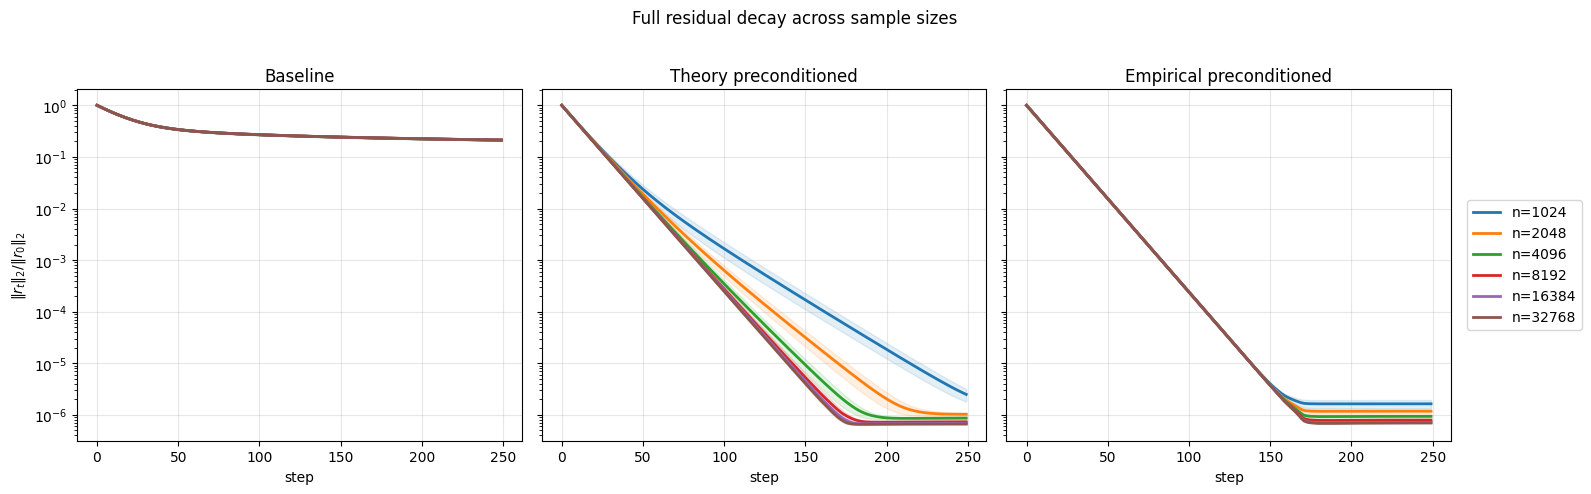

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

titles = ["Baseline", "Theory preconditioned", "Empirical preconditioned"]
keys   = ["loss_base", "loss_th", "loss_emp"]

for ax, title, key in zip(axes, titles, keys):
    for n in sorted(by_n.keys()):
        curves = []

        for run in by_n[n]:
            loss = np.asarray(run[key], dtype=float)

            # normalize: sqrt(loss / loss_0)
            norm_curve = np.sqrt(loss / max(loss[0], 1e-12))
            curves.append(norm_curve)

        curves = np.stack(curves, axis=0)

        steps = np.arange(curves.shape[1])
        mean = curves.mean(axis=0)
        std  = curves.std(axis=0)

        line = ax.plot(steps[:250], mean[:250], linewidth=2, label=f"n={n}")[0]

        ax.fill_between(
            steps[:250],
            mean[:250] - std[:250],
            mean[:250] + std[:250],
            alpha=0.12,
            color=line.get_color()
        )

    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$\|r_t\|_2 / \|r_0\|_2$")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.suptitle("Full residual decay across sample sizes", y=1.02)
plt.tight_layout()

filename = plot_path / "full_residual_decay_from_loss.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/base_residual_decay.png


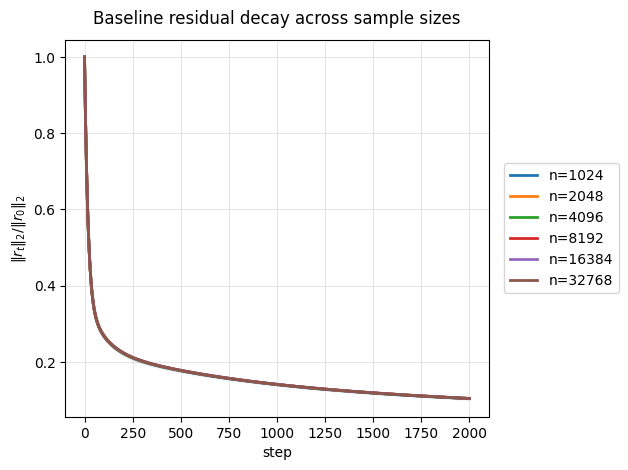

In [ ]:
titles = ["Baseline", "Theory preconditioned", "Empirical preconditioned"]
keys   = ["loss_base"]

for title, key in zip(titles, keys):
    for n in sorted(by_n.keys()):
        curves = []

        for run in by_n[n]:
            loss = np.asarray(run[key], dtype=float)

            # normalize: sqrt(loss / loss_0)
            norm_curve = np.sqrt(loss / max(loss[0], 1e-12))
            curves.append(norm_curve)

        curves = np.stack(curves, axis=0)

        steps = np.arange(curves.shape[1])
        mean = curves.mean(axis=0)
        std  = curves.std(axis=0)

        line = plt.plot(steps, mean, linewidth=2, label=f"n={n}")[0]

        plt.fill_between(
            steps,
            mean - std,
            mean + std,
            alpha=0.12,
            color=line.get_color()
        )

plt.yscale("log")
plt.xlabel("step")
plt.grid(True, alpha=0.3)

plt.ylabel(r"$\|r_t\|_2 / \|r_0\|_2$")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.title("Baseline residual decay across sample sizes", y=1.02)
plt.tight_layout()

filename = plot_path / "base_residual_decay.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

Using run: n=32768, seed=0
Modes plotted: ['const', 'cos_1', 'cos_2', 'sin_3', 'cos_7']
Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/mode_curve_compare_const_n32768_seed0.png


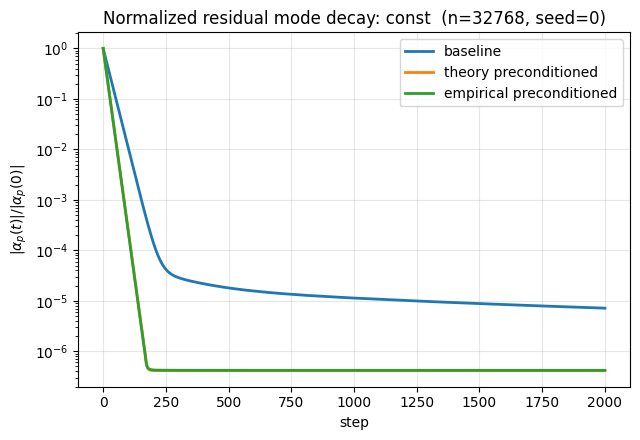

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/mode_curve_compare_cos_1_n32768_seed0.png


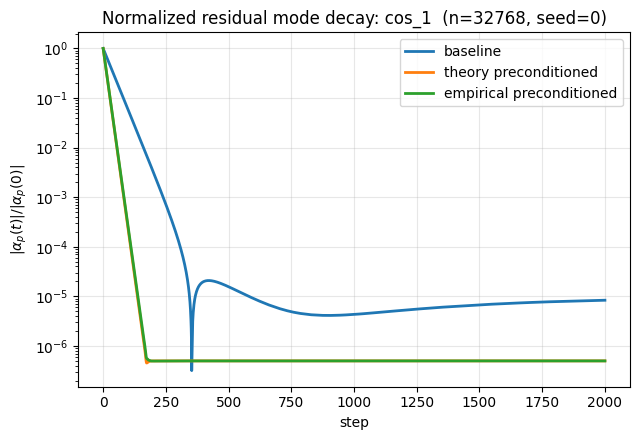

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/mode_curve_compare_cos_2_n32768_seed0.png


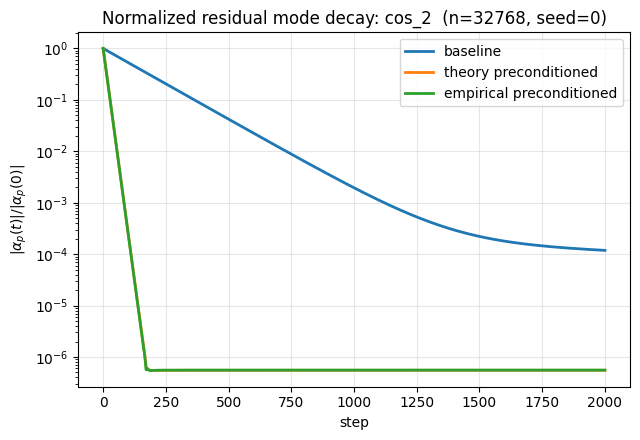

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/mode_curve_compare_sin_3_n32768_seed0.png


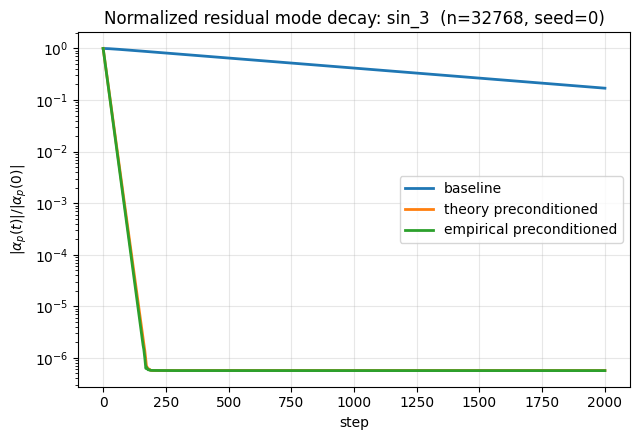

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/mode_curve_compare_cos_7_n32768_seed0.png


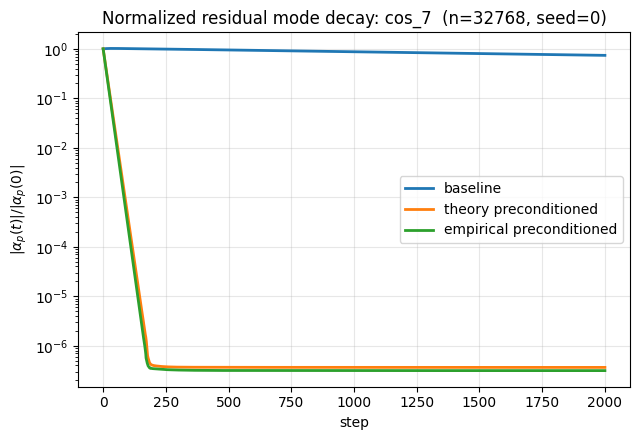

In [10]:
def _decode_name(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)


def _as_time_mode(arr, d_expected):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}")
    if arr.shape[1] == d_expected:
        return arr
    if arr.shape[0] == d_expected:
        return arr.T
    raise ValueError(f"Cannot interpret array with shape {arr.shape} and d_expected={d_expected}")


# choose which sample size / run to visualize
n_show = max(by_n.keys())          # change if you want, e.g. 512
seed_show = sorted(x["seed"] for x in by_n[n_show])[0]

run = next(x for x in by_n[n_show] if x["seed"] == seed_show)

mode_names = [_decode_name(x) for x in run["mode_names"]]
d = len(mode_names)

curves_base = _as_time_mode(run["mode_curves_base"], d)
curves_th = _as_time_mode(run["mode_curves_th"], d)
curves_emp = _as_time_mode(run["mode_curves_emp"], d)

steps = np.arange(curves_base.shape[0])

name_to_idx = {name: i for i, name in enumerate(mode_names)}

modes_to_plot = ["const", "cos_1", "cos_2", "cos_3", "cos_4"]

# for high frequency target
modes_to_plot = ["const", "cos_1", "cos_2", "sin_3", "cos_7", "sin_10"]

# for even higher frequency plots
modes_to_plot = ["const", "cos_1", "cos_2", "sin_3", "cos_7", "sin_10", "cos_12", "sin_15"]


modes_to_plot = [m for m in modes_to_plot if m in name_to_idx]

print(f"Using run: n={n_show}, seed={seed_show}")
print("Modes plotted:", modes_to_plot)

for mode_name in modes_to_plot:
    j = name_to_idx[mode_name]

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(steps, curves_base[:, j], linewidth=2, label="baseline")
    plt.plot(steps, curves_th[:, j], linewidth=2, label="theory preconditioned")
    plt.plot(steps, curves_emp[:, j], linewidth=2, label="empirical preconditioned")
    

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
    plt.title(f"Normalized residual mode decay: {mode_name}  (n={n_show}, seed={seed_show})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = plot_path / f"mode_curve_compare_{mode_name}_n{n_show}_seed{seed_show}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/all_mode_decay_three_panel_mean_std_n32768.png


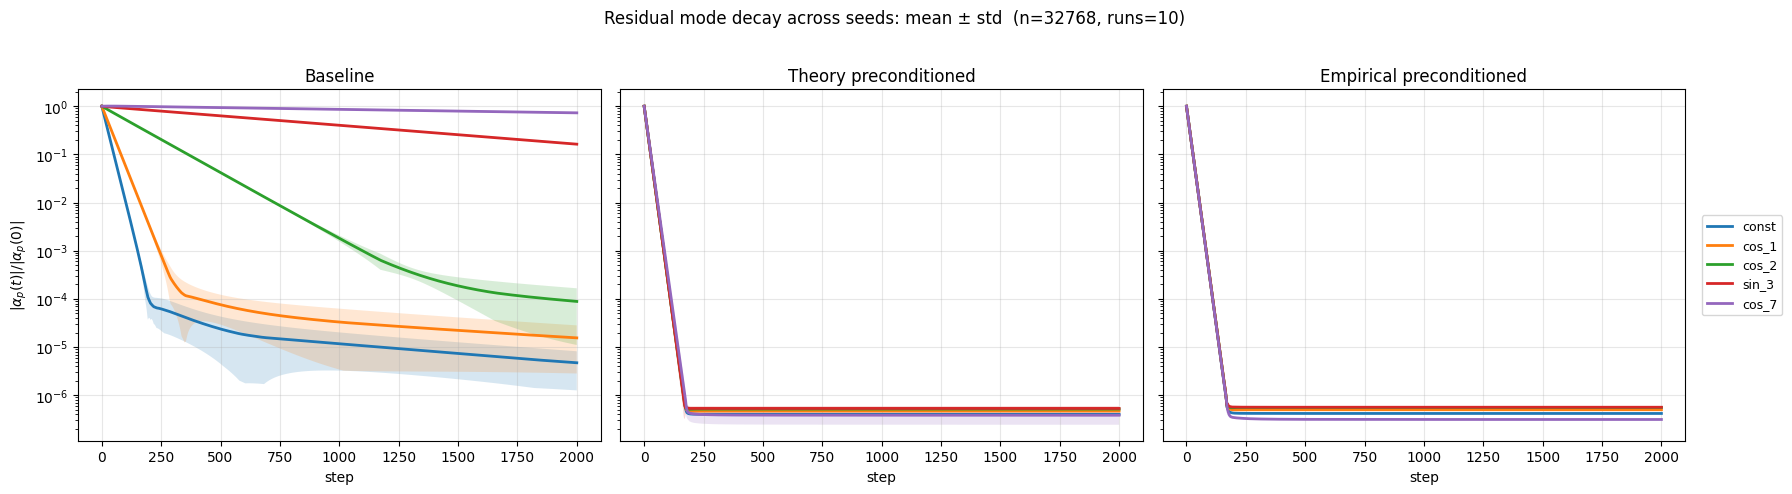

In [ ]:
def _decode_name(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)


def _as_time_mode(arr, d_expected):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}")
    if arr.shape[1] == d_expected:
        return arr
    if arr.shape[0] == d_expected:
        return arr.T
    raise ValueError(f"Cannot interpret array with shape {arr.shape} and d_expected={d_expected}")


def stack_curves_for_n(by_n, n, key):
    runs_n = by_n[n]
    mode_names = [_decode_name(x) for x in runs_n[0]["mode_names"]]
    d = len(mode_names)

    mats = []
    for run in runs_n:
        mats.append(_as_time_mode(run[key], d))   # shape [T, d]

    mats = np.stack(mats, axis=0)  # [num_runs, T, d]
    return mode_names, mats


# choose sample size to aggregate over seeds
n_show = max(by_n.keys())   # e.g. 512

mode_names, base_stack = stack_curves_for_n(by_n, n_show, "mode_curves_base")
_, th_stack = stack_curves_for_n(by_n, n_show, "mode_curves_th")
_, emp_stack = stack_curves_for_n(by_n, n_show, "mode_curves_emp")

steps = np.arange(base_stack.shape[1])

curve_sets = [
    ("Baseline", base_stack),
    ("Theory preconditioned", th_stack),
    ("Empirical preconditioned", emp_stack),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=True)

for ax, (title, stack) in zip(axes, curve_sets):
    mean = stack.mean(axis=0)   # [T, d]
    std = stack.std(axis=0)     # [T, d]

    for j, mode_name in enumerate(mode_names):
        if mode_name not in modes_to_plot:
            continue

        ax.plot(steps, mean[:, j], linewidth=2, label=mode_name)
        lower = np.clip(mean[:, j] - std[:, j], 1e-10, None)
        upper = np.clip(mean[:, j] + std[:, j], 1e-10, None)
        ax.fill_between(steps, lower, upper, alpha=0.18)

    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle(
    f"Residual mode decay across seeds: mean ± std  (n={n_show}, runs={len(by_n[n_show])})",
    y=1.02
)
fig.tight_layout()

filename = plot_path / f"all_mode_decay_three_panel_mean_std_n{n_show}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

dict_keys(['run_key', 'n', 'seed', 'mode_names', 'mode_curves_base', 'mode_curves_th', 'mode_curves_emp', 'y_pred_probe_base_final', 'y_pred_probe_th_final', 'y_pred_probe_emp_final', 'C_vs_Lambda_max', 'M_th_vs_emp_max', 'P_th_vs_emp_max', 'B_th_vs_emp_max', 'C_th_vs_emp_max', 'C_vs_Lambda_fro', 'M_th_vs_emp_fro', 'P_th_vs_emp_fro', 'B_th_vs_emp_fro', 'C_th_vs_emp_fro', 'loss_base', 'loss_th', 'loss_emp', 'eta', 'C', 'C_th', 'C_emp', 'lambda_n_diag', 'A', 'P_th', 'P_emp', 'B_th', 'B_emp', 'r_train_base', 'r_train_th', 'r_train_emp', 'mode_proj_base', 'mode_proj_th', 'mode_proj_emp'])
Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/probe_target_vs_prediction_three_panel_mean_std_n32768.png


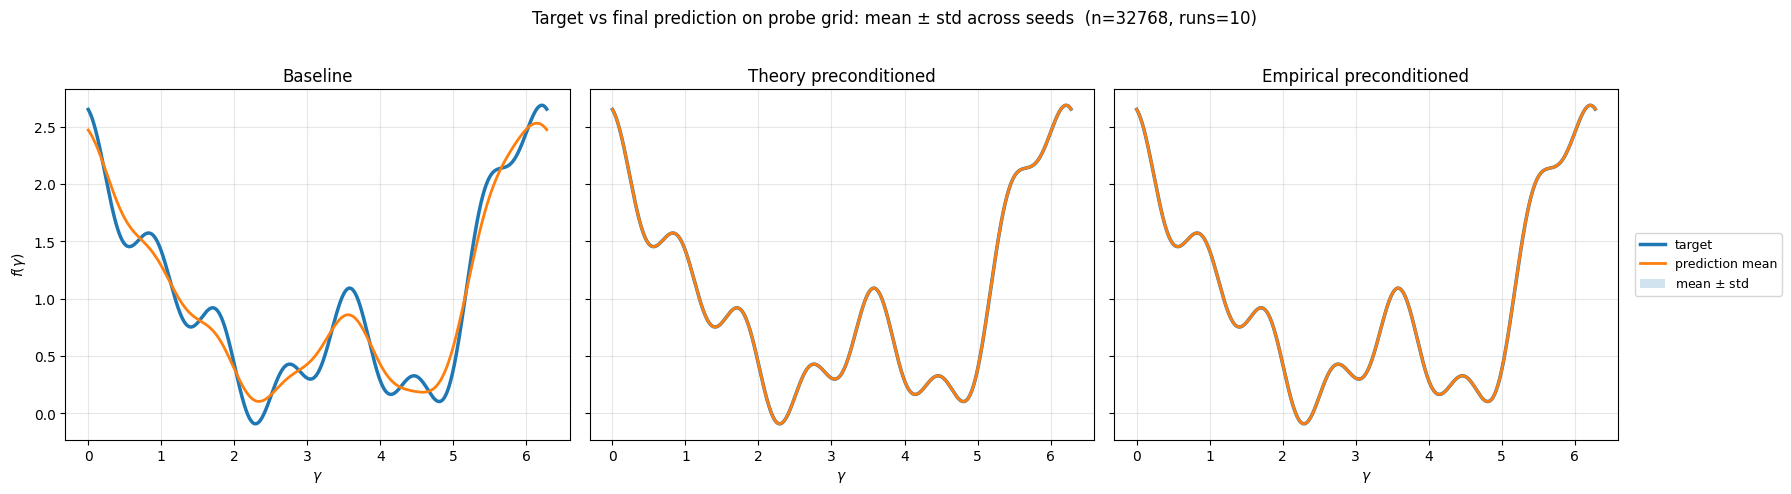

In [12]:
def stack_probe_preds_for_n(by_n, n, key):
    runs_n = by_n[n]
    mats = [np.asarray(run[key]) for run in runs_n]
    return np.stack(mats, axis=0)  # [num_runs, n_probe]

runs_n = by_n[4096]
print(runs_n[0].keys())

# choose sample size to aggregate over seeds
n_show = max(by_n.keys())   # e.g. 512

base_probe = stack_probe_preds_for_n(by_n, n_show, "y_pred_probe_base_final")
th_probe = stack_probe_preds_for_n(by_n, n_show, "y_pred_probe_th_final")
emp_probe = stack_probe_preds_for_n(by_n, n_show, "y_pred_probe_emp_final")

pred_sets = [
    ("Baseline", base_probe),
    ("Theory preconditioned", th_probe),
    ("Empirical preconditioned", emp_probe),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=True)

for ax, (title, preds) in zip(axes, pred_sets):
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)

    ax.plot(gamma_probe, y_target_probe, linewidth=2.5, label="target")
    ax.plot(gamma_probe, mean, linewidth=2.0, label="prediction mean")
    ax.fill_between(gamma_probe, mean - std, mean + std, alpha=0.2, label=r"mean $\pm$ std")

    ax.set_xlabel(r"$\gamma$")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$f(\gamma)$")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle(
    f"Target vs final prediction on probe grid: mean ± std across seeds  (n={n_show}, runs={len(by_n[n_show])})",
    y=1.02
)
fig.tight_layout()

filename = plot_path / f"probe_target_vs_prediction_three_panel_mean_std_n{n_show}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

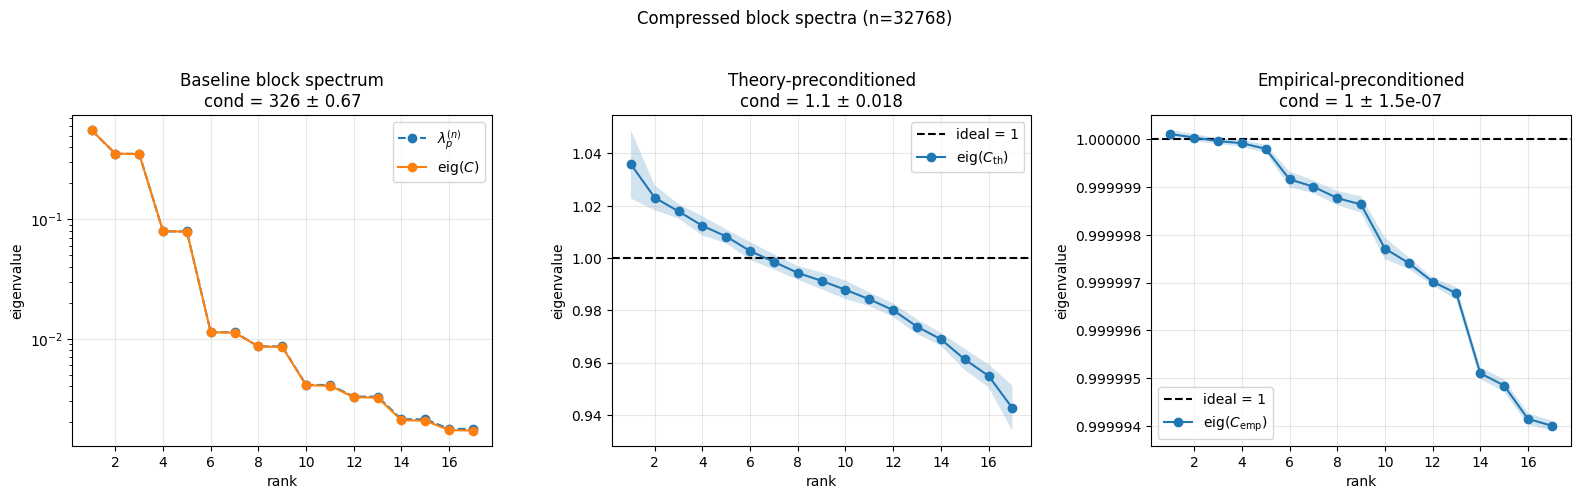

In [13]:
from core.kernel_analysis import continuum_fourier_eigenvalues_bias

REP_N = max(by_n.keys())   # or choose e.g. 512, 1024, 4096
runs_rep = by_n[REP_N]

d = runs_rep[0]["C"].shape[0]
ranks = np.arange(1, d + 1)

lambda_finite = np.asarray(runs_rep[0]["lambda_n_diag"], dtype=float)
lambda_finite_sorted = np.sort(lambda_finite)[::-1]

def safe_cond_from_eigs(eigs, eps=1e-14):
    eigs = np.asarray(eigs, dtype=float)
    eigs = np.real(eigs)
    eigs = eigs[np.isfinite(eigs)]
    if eigs.size == 0:
        return np.nan
    lam_max = np.max(eigs)
    lam_min = np.min(eigs)
    if lam_min <= eps:
        return np.inf
    return lam_max / lam_min

C_eigs_all = []
Cth_eigs_all = []
Cemp_eigs_all = []

C_conds = []
Cth_conds = []
Cemp_conds = []

for r in runs_rep:
    C = np.asarray(r["C"], dtype=float)
    C_th = np.asarray(r["C_th"], dtype=float)
    C_emp = np.asarray(r["C_emp"], dtype=float)

    eig_C = np.sort(np.real(np.linalg.eigvals(C)))[::-1]
    eig_Cth = np.sort(np.real(np.linalg.eigvals(C_th)))[::-1]
    eig_Cemp = np.sort(np.real(np.linalg.eigvals(C_emp)))[::-1]

    C_eigs_all.append(eig_C)
    Cth_eigs_all.append(eig_Cth)
    Cemp_eigs_all.append(eig_Cemp)

    C_conds.append(safe_cond_from_eigs(eig_C))
    Cth_conds.append(safe_cond_from_eigs(eig_Cth))
    Cemp_conds.append(safe_cond_from_eigs(eig_Cemp))

C_eigs_all = np.stack(C_eigs_all, axis=0)
Cth_eigs_all = np.stack(Cth_eigs_all, axis=0)
Cemp_eigs_all = np.stack(Cemp_eigs_all, axis=0)

C_mean, C_std = C_eigs_all.mean(axis=0), C_eigs_all.std(axis=0)
Cth_mean, Cth_std = Cth_eigs_all.mean(axis=0), Cth_eigs_all.std(axis=0)
Cemp_mean, Cemp_std = Cemp_eigs_all.mean(axis=0), Cemp_eigs_all.std(axis=0)

C_cond_mean, C_cond_std = np.mean(C_conds), np.std(C_conds)
Cth_cond_mean, Cth_cond_std = np.mean(Cth_conds), np.std(Cth_conds)
Cemp_cond_mean, Cemp_cond_std = np.mean(Cemp_conds), np.std(Cemp_conds)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)

# --- Baseline block spectrum ---
ax = axes[0]
ax.plot(ranks, lambda_finite_sorted, marker="o", linestyle="--", label=r"$\lambda_p^{(n)}$")
ax.plot(ranks, C_mean, marker="o", label=r"eig$(C)$")
ax.fill_between(
    ranks,
    np.maximum(C_mean - C_std, 1e-16),
    C_mean + C_std,
    alpha=0.2,
)
ax.set_yscale("log")
ax.set_xlabel("rank")
ax.set_ylabel("eigenvalue")
ax.set_title(f"Baseline block spectrum\ncond = {C_cond_mean:.3g} ± {C_cond_std:.2g}")
# ax.set_title("Baseline block spectrum")
ax.grid(True, alpha=0.3)
ax.legend()

# --- Theory-preconditioned block spectrum ---
ax = axes[1]
ax.axhline(1.0, linestyle="--", color="black", label=r"ideal = 1")
ax.plot(ranks, Cth_mean, marker="o", label=r"eig$(C_{\mathrm{th}})$")
ax.fill_between(
    ranks,
    Cth_mean - Cth_std,
    Cth_mean + Cth_std,
    alpha=0.2,
)
ax.set_xlabel("rank")
ax.set_ylabel("eigenvalue")
# ax.set_title("Theory-preconditioned block spectrum")
ax.set_title(f"Theory-preconditioned\ncond = {Cth_cond_mean:.3g} ± {Cth_cond_std:.2g}")
ax.grid(True, alpha=0.3)
ax.legend()

# --- Empirical-preconditioned block spectrum ---
ax = axes[2]
ax.axhline(1.0, linestyle="--", color="black", label=r"ideal = 1")
ax.plot(ranks, Cemp_mean, marker="o", label=r"eig$(C_{\mathrm{emp}})$")
ax.fill_between(
    ranks,
    Cemp_mean - Cemp_std,
    Cemp_mean + Cemp_std,
    alpha=0.2,
)
ax.set_xlabel("rank")
ax.set_ylabel("eigenvalue")
# ax.set_title("Empirical-preconditioned block spectrum")
ax.set_title(f"Empirical-preconditioned\ncond = {Cemp_cond_mean:.3g} ± {Cemp_cond_std:.2g}")
ax.grid(True, alpha=0.3)
ax.yaxis.get_major_formatter().set_useOffset(False)
ax.legend()

plt.suptitle(f"Compressed block spectra (n={REP_N})", y=1.03)
filename = plot_path / f"compressed_block_spectra_{REP_N}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

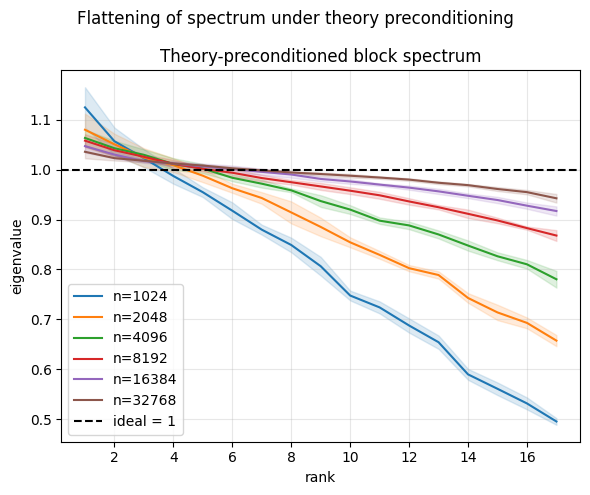

In [57]:
N_list = sorted(by_n.keys())

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

for REP_N in N_list:
    runs_rep = by_n[REP_N]

    d = runs_rep[0]["C_th"].shape[0]
    ranks = np.arange(1, d + 1)

    Cth_eigs_all = []

    for r in runs_rep:
        C_th = np.asarray(r["C_th"], dtype=float)
        eigs = np.sort(np.real(np.linalg.eigvals(C_th)))[::-1]
        Cth_eigs_all.append(eigs)

    Cth_eigs_all = np.stack(Cth_eigs_all, axis=0)

    Cth_mean = Cth_eigs_all.mean(axis=0)
    Cth_std  = Cth_eigs_all.std(axis=0)

    label = f"n={REP_N}"

    line = ax.plot(ranks, Cth_mean, label=label)[0]
    color = line.get_color()
    ax.fill_between(ranks, Cth_mean - Cth_std, Cth_mean + Cth_std,
                    color=color, alpha=0.15)

# Ideal line
ax.axhline(1.0, linestyle="--", color="black", label="ideal = 1")

# Decorations
ax.set_title("Theory-preconditioned block spectrum")
ax.set_xlabel("rank")
ax.set_ylabel("eigenvalue")
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle("Flattening of spectrum under theory preconditioning")
plt.tight_layout()
plt.savefig(plot_path / "theory_preconditioned_spectrum_all_n.png",
            dpi=300, bbox_inches="tight")
plt.show()